In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson
import pandas as pd

## Biophysics

This notebook will be reserved for the solution of problems suggested in the book *Biophysics: Searching for fundamental principles* by *William Bialek* and digressions that come with it. 

We start by thinking about how to model light. Light comes in packages (photons) and these packages are released in collections in time, therefore the first thing we need to do is to model how these photons are realeased and consequently absorbed by the eye. 

The **light statistics** of the sources are generally modeled by Poisson Process, which have a probability of sending **n** photons, given by the *Poisson Distribution*. So this will be the starting point to attempt to model how our eyes absorb these photons and with what probability. 

### P.3: Simulating a Poisson Process

Before starting the simulation, let us formally define the underlying mathematical framework:

**Definition 1: Poisson Random Variable** A random variable $X$ with parameter $\lambda$ follows a Poisson distribution if its probability mass function is given by:
$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

**Definition 2: Counting Process** A counting process $\{N(t), t \geq 0\}$ is a stochastic process that represents the total number of events that have occurred up to time $t$.

**Definition 3: Poisson Process** A Poisson process is a counting process that satisfies the following conditions:
1. $N(0) = 0$.
2. **Independent Increments:** For any disjoint time intervals $[t_j, t_i]$ and $[t_l, t_k]$, the number of events occurring in those intervals are independent random variables.
3. **Stationary Increments:** The distribution of the number of events in any interval depends only on the length of the interval. Specifically, there exists a rate $\lambda > 0$ such that for any $t > 0$ and $h > 0$, the expected number of events is $E[N(t+h) - N(t)] = \lambda h$.
4. **Single Event Probability:** The probability of exactly one event occurring in a small interval $h$ is $P(N(h) = 1) = \lambda h + o(h)$.
5. **No Simultaneous Events:** The probability of two or more events occurring in a small interval $h$ is negligible: $P(N(h) \geq 2) = o(h)$.

A function $f(h)$ is said to be $o(h)$ if:
$$\lim_{h \rightarrow 0} \frac{f(h)}{h} = 0$$

From these postulates, it can be derived that for any interval of length $t$, the number of events $n$ follows a Poisson distribution with mean $\lambda t$:
$$P[N(t) = n] = \frac{e^{-\lambda t} (\lambda t)^n}{n!}$$

Total events simulated: 4967
Target rate: 5 events/s
Actual rate: 4.97 events/s


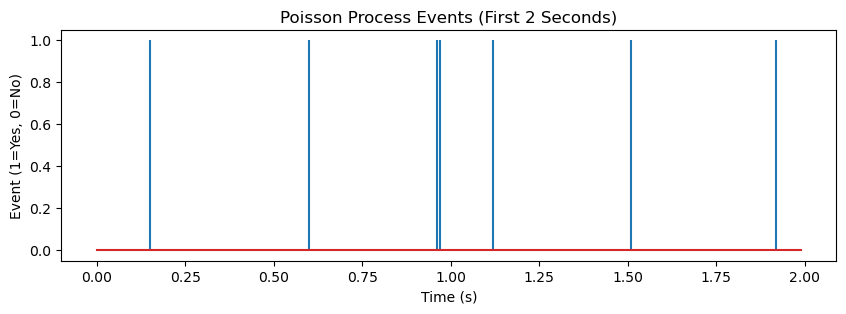

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 1000      # Total time in seconds
r_bar = 5       # Average rate (events/sec)
dt = 0.01        # Time step (small bin size)

# Derived parameters
num_bins = int(T / dt)
prob_event = r_bar * dt  # Threshold probability

# 1. Generate random numbers for every bin
# np.random.rand is the direct equivalent to MATLAB's rand
random_values = np.random.rand(num_bins)

# 2. Compare against threshold
# We place an event (1) if the random value is LESS than our probability
events = (random_values < prob_event).astype(int)


actual_event_count = np.sum(events)
actual_rate = actual_event_count / T

print(f"Total events simulated: {actual_event_count}")
print(f"Target rate: {r_bar} events/s")
print(f"Actual rate: {actual_rate:.2f} events/s")


plt.figure(figsize=(10, 3))
time_axis = np.arange(0, 2, dt)
plt.stem(time_axis, events[:len(time_axis)], markerfmt=' ')
plt.title("Poisson Process Events (First 2 Seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Event (1=Yes, 0=No)")
plt.show()

We know that in number of events in any interval of a Poisson Process, is given by the poisson distribution. Therefore we expect the mean and variance to be equal and the mean to be equal to the $\lambda dt$

In [51]:
import numpy as np

taus = [1,3, 5, 10]

for tau in taus:
    counts = [] 
    
    # Calculate how many bins fit into one tau
    bins_per_tau = int(tau / dt)
    # Calculate how many full tau windows fit in T
    num_windows = int(T / tau)
    
    for i in range(num_windows):
        
        start = i * bins_per_tau
        end = (i + 1) * bins_per_tau
        events_tau = events[start:end]
        
        counts.append(np.sum(events_tau))
    
    mean = np.mean(counts)
    var = np.var(counts)
    
    print(f"Interval (tau): {tau}s")
    print(f"Theoretical Mean (r*tau): {r_bar * tau}")
    print(f"Interval Mean: {mean:.2f}")
    print(f"Interval Variance: {var:.2f}")
    print(f"Ratio (Var/Mean): {var/mean:.2f}") # Should be close to 1
    print('-------------------------')

Interval (tau): 1s
Theoretical Mean (r*tau): 5
Interval Mean: 4.97
Interval Variance: 4.61
Ratio (Var/Mean): 0.93
-------------------------
Interval (tau): 3s
Theoretical Mean (r*tau): 15
Interval Mean: 14.91
Interval Variance: 13.79
Ratio (Var/Mean): 0.93
-------------------------
Interval (tau): 5s
Theoretical Mean (r*tau): 25
Interval Mean: 24.84
Interval Variance: 24.41
Ratio (Var/Mean): 0.98
-------------------------
Interval (tau): 10s
Theoretical Mean (r*tau): 50
Interval Mean: 49.67
Interval Variance: 52.26
Ratio (Var/Mean): 1.05
-------------------------


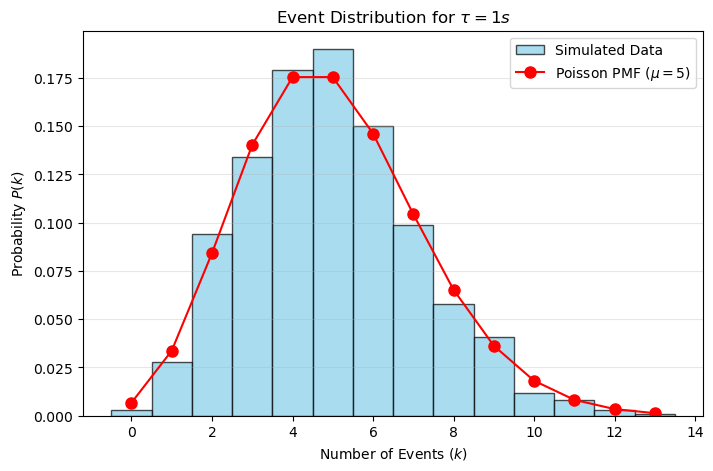

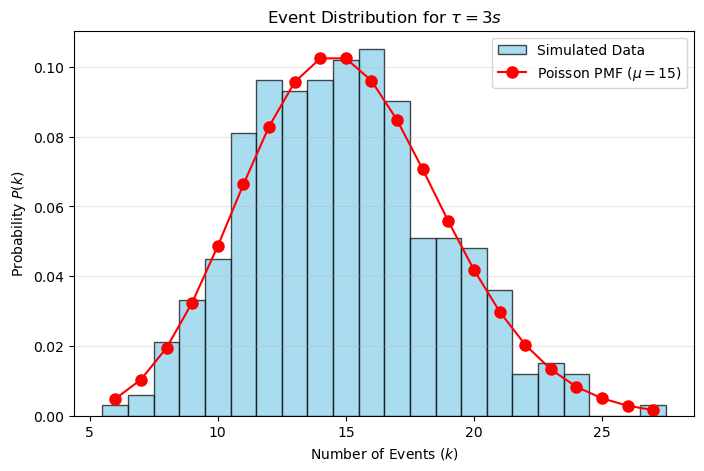

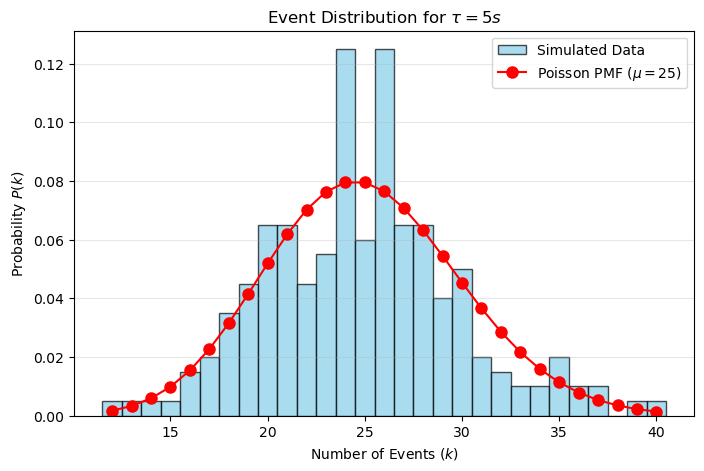

In [52]:
# Assuming r_bar, dt, and events are already defined
taus = [1,3,5]

for tau in taus:
    # --- 1. Slicing logic (same as before) ---
    counts = []
    bins_per_tau = int(round(tau / dt))
    num_windows = int(len(events) // bins_per_tau)
    
    for i in range(num_windows):
        start = i * bins_per_tau
        end = (i + 1) * bins_per_tau
        counts.append(np.sum(events[start:end]))

    # --- 2. Plotting ---
    plt.figure(figsize=(8, 5))
    
    # Plot the histogram of your simulated data
    # density=True makes it a probability distribution instead of raw counts
    plt.hist(counts, bins=np.arange(min(counts), max(counts) + 2) - 0.5, 
             density=True, alpha=0.7, color='skyblue', label='Simulated Data', edgecolor='black')

    # Calculate the theoretical Poisson distribution
    mu = r_bar * tau
    x = np.arange(min(counts), max(counts) + 1)
    y = poisson.pmf(x, mu)
    
    # Plot the theoretical points
    plt.plot(x, y, 'ro-', ms=8, label=f'Poisson PMF ($\mu={mu}$)')

    plt.title(f'Event Distribution for $\\tau = {tau}s$')
    plt.xlabel('Number of Events ($k$)')
    plt.ylabel('Probability $P(k)$')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

### Exercise 5



### The Probability of Detection

The probability of an observer perceiving a flash of intensity $I$ is given by the cumulative Poisson distribution:

$$P_{\text{see}}(I) = \sum_{n=K}^{\infty}P(n|M = \alpha I) = e^{-\alpha I} \sum_{n=K}^{\infty}\frac{(\alpha I)^n}{n!}$$

In this model, $M = \alpha I$ represents the **mean number of absorbed quanta**. The variable $I$ denotes the physical intensity (energy) of the flash, while $\alpha$ is a constant representing the **visual efficiency** of the specific observer. This constant accounts for biological factors such as the transmission of light through the eye and the probability of a photon being successfully absorbed by rhodopsin.

---


This analysis focuses on the classic study *"Energy, Quanta, and Vision"* (1942). We are working specifically with **Table V: Energy and Frequency of Seeing** (page 17). I will first reproduce the experimental data tables and then proceed with the exercise, which investigates the statistical implications of averaging the data across different observation series.

#### Experimental Concept

The experiment worked as follows:

* **Observers:** Three dark-adapted observers (the authors themselves) performed the trials in a darkened room.
* **Stimuli:** The observers were presented with flashes of light of known energy. From these energy levels, the average number of quanta per flash could be calculated.
* **Task:** This was a **Yes/No detection task**. The observer simply reported whether or not they perceived the light.
* **Procedure:** Each intensity was tested multiple times (typically 50 trials, though S. Hecht had series of 35 and 40) to determine the "frequency of seeing" for each specific energy level.

By assuming that the number of photons follows a **Poisson distribution**, we can fit these "frequency of seeing" curves to the equation above. This allows us to estimate the value of $K$—the minimum number of photons required for the human eye to register a visual sensation.


In [157]:
df_mhp = pd.read_csv('Data/MHP_data.csv')

df_ss = pd.read_csv('Data/SS_data.csv')
df_ss2 = pd.read_csv('Data/SS_2_data.csv')


df_sh = pd.read_csv('Data/SH_data.csv')
df_sh2 = pd.read_csv('Data/SH_2_data.csv')



In [158]:
list_ = ( (df_sh['No_of_quanta'] + df_sh2['No_of_quanta'])/2 + (df_ss['No_of_quanta'] + df_ss2['No_of_quanta'])/2 + df_mhp['No_of_quanta'])/3

In [159]:
list_2 = ( (df_sh['Frequency_percent'] + df_sh2['Frequency_percent'])/2 + (df_ss['Frequency_percent'] + df_ss2['Frequency_percent'])/2 + df_mhp['Frequency_percent'])/3



In [160]:
data = {'No_of_quanta': list_, 'Frequency_percent':list_2}
df_matrix = pd.DataFrame(data)

In [161]:
df_matrix

,No_of_quanta,Frequency_percent
0,34.466667,2.000000
1,53.916667,5.483333
2,84.300000,25.216667
3,132.283333,63.916667
4,208.083333,93.583333
5,325.716667,100.000000


In [162]:
'''for i in data:
    i.drop(columns = ['Subject'], inplace = True) 
    ### inplace drops the column of the existing dataframe. Since
    ### pandas drop function creates a new dataframe
    I will not be using this anymore since it is not recommended in pandas to use inplace = True or doing it iteratively
    since it is not memory efficient (creates new copies) and the best way is to explicitly reassingn this functions, 
    like i will do soon
'''                                                  

"for i in data:\n    i.drop(columns = ['Subject'], inplace = True) \n    ### inplace drops the column of the existing dataframe. Since\n    ### pandas drop function creates a new dataframe\n    I will not be using this anymore since it is not recommended in pandas to use inplace = True or doing it iteratively\n    since it is not memory efficient (creates new copies) and the best way is to explicitly reassingn this functions, \n    like i will do soon\n"

In [163]:
def clean_df(data):
    data = data.drop(columns = ['Subject'], errors = 'ignore') 
    ### if you run the cell twice and it cant find the column, errors = 'ignore' guarantees it wont crash     
    if 'Frequency_percent' in data.columns:
        data['Frequency_percent'] = data['Frequency_percent']/100
        data = data.rename(columns = {'Frequency_percent': 'prob'})
        
    if 'No_of_quanta' in data.columns:
        data['No_of_quanta'] = np.log10(data['No_of_quanta'])
        data = data.rename(columns = {'No_of_quanta': 'quanta'})
        
    return data

df_mhp = clean_df(df_mhp)

df_ss = clean_df(df_ss)
df_ss2 = clean_df(df_ss2)

dfm_ss = (df_ss+df_ss2)/2

df_sh = clean_df(df_sh)
df_sh2 = clean_df(df_sh2)
dfm_sh = (df_sh+df_sh2)/2

df_mean = clean_df(df_matrix)

In [164]:
df_sh

,quanta,prob
0,1.671173,0.000
1,1.863917,0.094
2,2.056142,0.333
3,2.248954,0.735
4,2.441066,1.000
5,2.625004,1.000


In [174]:
### Cumulative poisson distribution using Scipy
def prob_see_scipy(alpha, I, K):
    mean = alpha * I
    # poisson.sf(k, mu) calculates P(X > k)
    # We want P(X >= K), which is equivalent to P(X > K-1)
    return poisson.sf(K - 1, mean)

In [166]:
quantass = np.linspace(10**1.3, 10**2.5, 500)*1

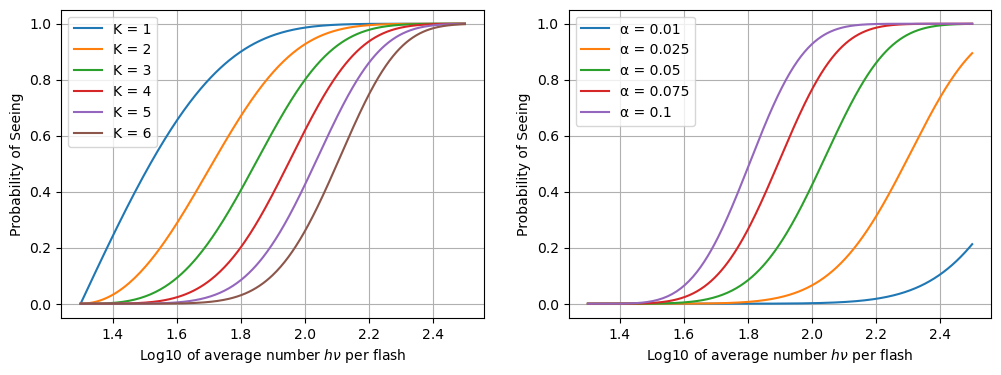

In [167]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (12,4))

axes= [ax1, ax2]


alpha = [0.01, 0.025, 0.05, 0.075, 0.1]
K = [1,2,3,4,5,6]
quanta2 = np.linspace(0, 10**2.5, 500) 
for i in K:
    ax1.plot(np.log10(quantass), [prob_see_scipy(0.05, j, i) for j in quanta2], label = f'K = {i}')

for i in alpha:
    ax2.plot(np.log10(quantass), [prob_see_scipy(i, j, 5) for j in quanta2], label = f'α = {i}')


for ax in axes: 
    ax.set_xlabel(r'Log10 of average number $h\nu$ per flash')
    ax.set_ylabel('Probability of Seeing')
    ax.grid()
    ax.legend()
    

plt.show()

The graph above is a simulation which shows that given a constant $\alpha$ the change in K (# of photons) simply make the curve steeper. Simultaneously the increase in $\alpha$, when K is constant moves the curve to the left.
This is key, because it gave the researchers an opportunity to test if the data they collected would fit this *cumulative poisson distribution*, that, as shown before, describes the number of photons detected given a thermal source. The next cell shows their data fitted with this function. 

Using the logarithm is also a very important part of the investigation of this problem. As Hecht et al poses:

--------
"Another and equally important feature of Fig. 6 is that the relationship is expressed in terms of the logarithm of the average number of quanta per flash. Therefore, for comparison with the distributions in Fig. 6, the experiments need not employ the absolute values of the average number of quanta delivered per flash, but merely their relative values"

-------

$$
I_{total} = I_{cornea}*c
$$

Where c is a constant which comprises the loss of intensity after passing through the cornea, since what they measure was the light emited ($I_t > I_c$).


$$
log(I_{total}) = log(E_{cornea}c) = log(E_{cornea}) + log(c)
$$

So the curve is not affected by this constant.

Notice in the graph below that one curve has been altered, while the other simply shifted to the right. The essential information is the curve of the function.


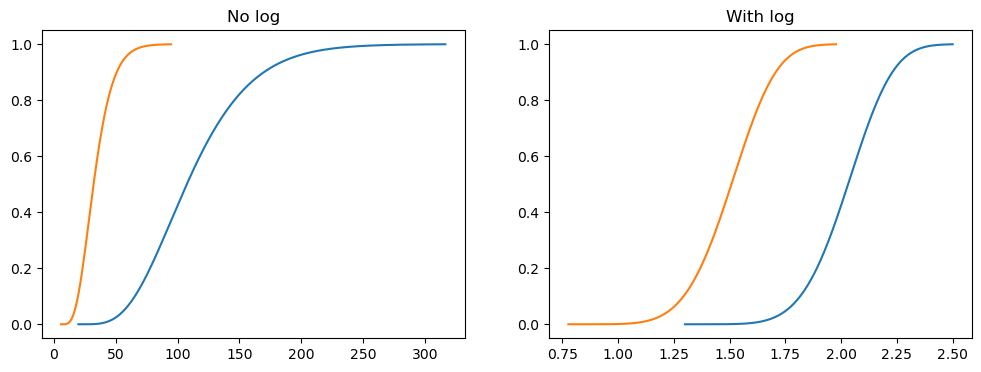

In [169]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (12,4))
quantas = np.linspace(0, 10**2.5, 500) 

ax1.plot((quantass), [prob_see_scipy(0.05, j, 5) for j in quanta2])
ax1.plot((quantass)*0.3, [prob_see_scipy(0.05, j, 5) for j in quanta2])
ax1.set_title('No log')

ax2.plot(np.log10(quantass), [prob_see_scipy(0.05, j, 5) for j in quanta2], label = f'K = {i}')
ax2.plot(np.log10(quantass) + np.log10(0.3), [prob_see_scipy(0.05, j, 5) for j in quanta2], label = f'K = {i}')
ax2.set_title('With log')
plt.show()


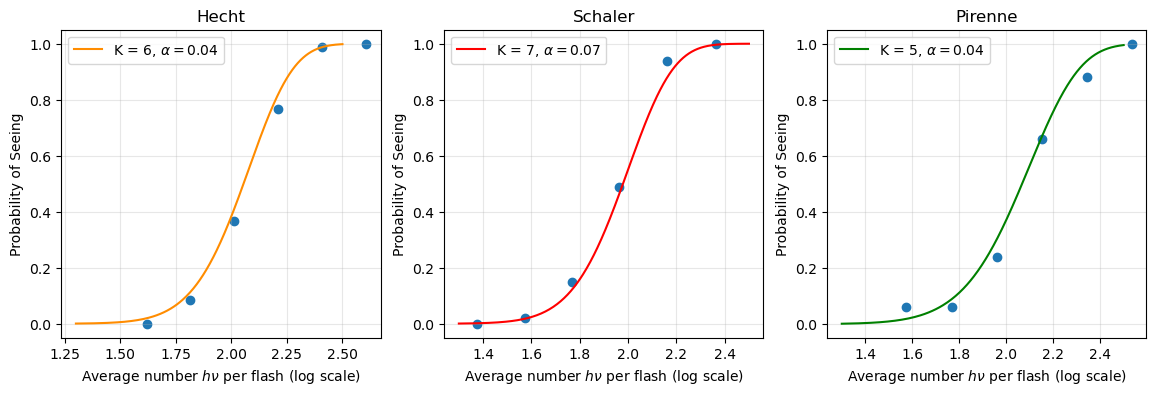

In [178]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize = (14,4))


axes = [ax1,ax2,ax3]
ax1.set_title('Hecht')
#ax1.scatter(df_sh['quanta'], df_sh['prob'])
#ax1.scatter(df_sh2['quanta'], df_sh2['prob'])
ax1.scatter(dfm_sh['quanta'], dfm_sh['prob'])

fit_ss = [prob_see_scipy(0.05, j, 6) for j in quantass]
ax1.plot(np.log10(quantass), fit_ss, label = r'K = 6, $\alpha = 0.04$', c = 'darkorange')

ax2.set_title('Schaler')
#ax2.scatter(df_ss['quanta'], df_sh['prob'])
#ax2.scatter(df_ss2['quanta'], df_sh2['prob'])
ax2.scatter(dfm_ss['quanta'], dfm_ss['prob'])


fit_sh = [prob_see_scipy(0.07, j, 7) for j in quantass]
ax2.plot(np.log10(quantass), fit_sh, label = r'K = 7, $\alpha = 0.07$', c = 'r')


ax3.set_title('Pirenne')
ax3.scatter((df_mhp['quanta']), df_mhp['prob'])
fit_mhp = [prob_see_scipy(0.04, j, 5) for j in quantass]
ax3.plot(np.log10(quantass), fit_mhp, label = r'K = 5, $\alpha = 0.04$', c = 'g')



for ax in axes:
    ax.set_xlabel(r'Average number $h\nu$ per flash (log scale)')
    ax.set_ylabel('Probability of Seeing')
    #ax.set_xscale('log')
    # You can also add grids or limits here
    ax.grid(True, alpha=0.3)
    ax.legend()
    



plt.show()

I attempt to plot the distributions with the number of photons stated on the experiment and $\alpha$ was determined to best fit the data. There is no specific mention for the $\alpha$ on the article, but it is mentioned on the book. It is clear that it changes person to person. The change in $\alpha$, however, only gives us information on intrinsic eye characteristics of each observer, what really interests us is the K (# of photons). As it is shown the numbers vary from 5 to 7, given that the part of the human eye which was exposed to light (periphery) has thousands of rod cells it makes stastical sense that the rods are absorving at single photons. 


## Introducing Noise: Barlow "Retinal Noise and Absolute Threshold"

Barlow model introduces retinal noise, which comes from the thermal decomposition of rhodopsin, in order to explain more of the variability of visual perception. His assumption comes from the fact that he knows that noise limits the sensitivity, which would alter the threshold, and he would like to determine this noise in the earliest possible point of this whole process. This step assumes that the process of defining a threshold is made by the distinction of noise from signal and not necessarely from *a priori* definitions of a threshold. 

These *dark photons* were later found to exist and justify his assumptions. Although many other noise processes can also be considered, such as noise in the neural pathways.  We call them *dark photons*, because they also follow poisson distributions, and this can be derived thinking that the probability of the decomposition is independent of the number of similar events in the past or neighboring retina (also follows a Poisson Process). The cumulative distribution which describes the probability of seeing is:


$$
P_{\text{see}}(a) = e^{-a} \sum_{y=K}^{\infty}\frac{(a)^y}{y!}
$$

Where:

* N = average number of quanta at cornea from a flash
* n = avg. number of quanta which provoke a stimulus;
* x = avg. number of dark photons;
* a = n + x: total number of events;
* K = threshold of photons;

So we must determine the parameters $(x, n/N, K)$. Note that $n/N$ is a very important factor: it refers to the fraction of quanta incident on the cornea which are effective in exciting rods. 

Notice we can also determine the probability of false positive responses calculating $P_{see}(x)$, which gives me the probability of seeing given that the average number of events which stimulated the optical process is solely due to dark photons. 

In [69]:
def barlow_model(N, n_over_N, x, c): # number of quanta, stimuli/total, noise, threshold
    # a is the total mean: (efficiency * quanta) + noise
    a = (n_over_N * N) + x
    return poisson.sf(c - 1 , a)

--- Barlow Model Fit Results: SH (Hecht) ---
Efficiency (n/N): 0.0988
Retinal Noise (x): 10.05
Threshold (K): 24
False Positive Rate: 0.000129 (0.0129%)

--- Barlow Model Fit Results: MHP (Pirenne) ---
Efficiency (n/N): 0.0767
Retinal Noise (x): 11.74
Threshold (K): 22
False Positive Rate: 0.004774 (0.4774%)

--- Barlow Model Fit Results: SS (Shlaer) ---
Efficiency (n/N): 0.1456
Retinal Noise (x): 8.00
Threshold (K): 21
False Positive Rate: 0.000094 (0.0094%)



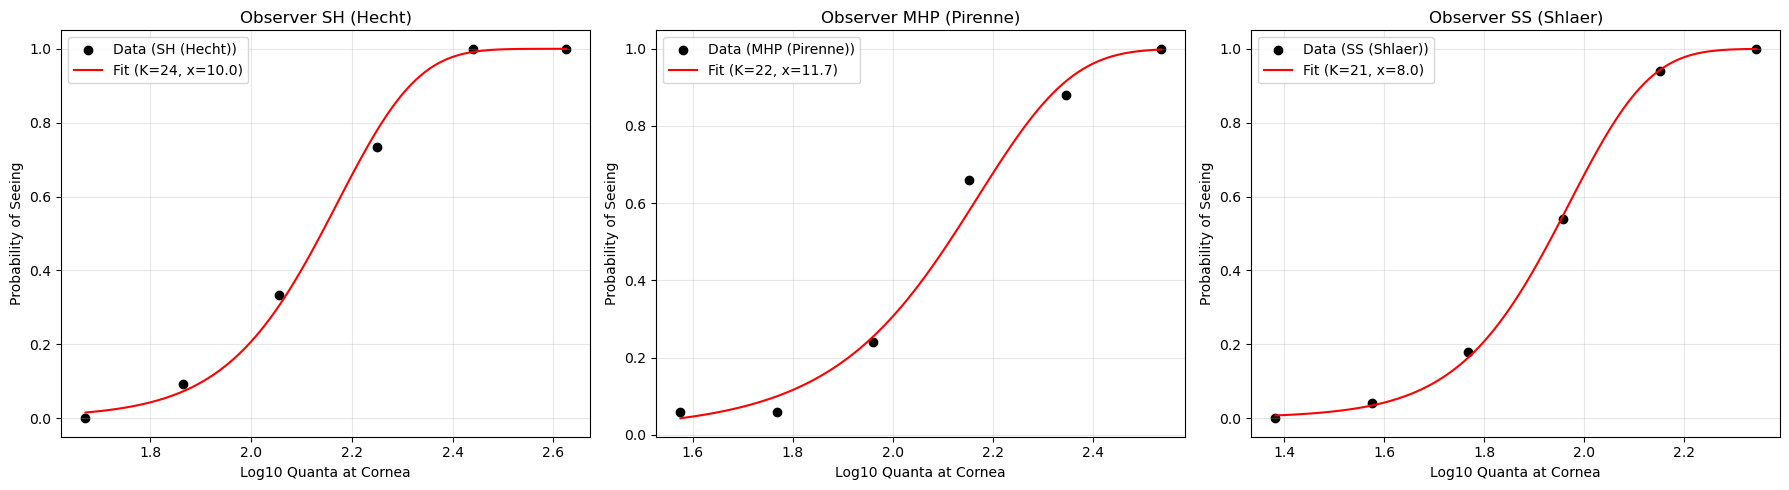

In [203]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import poisson
bests = []
# List of your dataframes and their corresponding labels
datasets = [
    (df_sh, 'SH (Hecht)'),
    (df_mhp, 'MHP (Pirenne)'),
    (df_ss, 'SS (Shlaer)')
]

# Set up the figure for three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_trials = 50  # Trials per intensity point [cite: 109]

for i, (df, label) in enumerate(datasets):
    # 1. Prepare data
    N_linear = 10**df['quanta'].values 
    seen_counts = df['prob'].values * n_trials

    # 2. Run Optimization using Barlow's initial guesses [cite: 135, 186]
    initial_guess = [0.13, 8.9, 21]
    res = minimize(barlow_nll_df, initial_guess, 
                   args=(N_linear, seen_counts, n_trials), 
                   method='Nelder-Mead')

    best_eff, best_x, best_c = res.x
    

    bests.append((best_eff,best_x, best_c))
    best_c_int = int(round(best_c))
    
    # 3. Calculate False Positive Rate 
    fp_rate = poisson.sf(best_c_int - 1, best_x)

    # Print Results
    print(f"--- Barlow Model Fit Results: {label} ---")
    print(f"Efficiency (n/N): {best_eff:.4f}")
    print(f"Retinal Noise (x): {best_x:.2f}")
    print(f"Threshold (K): {best_c_int}")
    print(f"False Positive Rate: {fp_rate:.6f} ({fp_rate*100:.4f}%)\n")

    # 4. Plotting
    ax = axes[i]
    ax.scatter(df['quanta'], df['prob'], label=f'Data ({label})', color='black')
    
    # Generate smooth fit line [cite: 164, 166]
    log_N_smooth = np.linspace(df['quanta'].min(), df['quanta'].max(), 100)
    y_fit = barlow_model(10**log_N_smooth, best_eff, best_x, best_c_int)
    
    ax.plot(log_N_smooth, y_fit, 'r-', 
            label=f'Fit (K={best_c_int}, x={best_x:.1f})')
    
    ax.set_title(f'Observer {label}')
    ax.set_xlabel('Log10 Quanta at Cornea')
    ax.set_ylabel('Probability of Seeing')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Notice that the best fit assumes a large increase in the threshold and also adds a large amount of noise in the system. Though the false positive rate is still quite small.

* Hecht went from K = 6 to K = 24;
* Pirenne went from K = 5 to K = 22;
* Shlaer went from K = 7 to K = 21;


These results are merely a demonstration of the ideias behind this model and no real interpretation is going to be given at this moment. 

In [204]:
bests

[(0.0987538885554095, 10.04756842270914, 24.295112091416513),
 (0.07669589495774987, 11.743092819026607, 22.08392148948215),
 (0.14559030775636542, 8.001576534221797, 21.405545933672457)]

--- Reliability Comparison ---
Case 1 (c=24.3, x=10.0): FP Rate = 0.000129 (0.0129%)
Case 2 (c=20.0, x=10.0): FP Rate = 0.003635 (0.3635%)
The decrease in threshold multiplied the False Positive rate by a factor of ~28.2x.


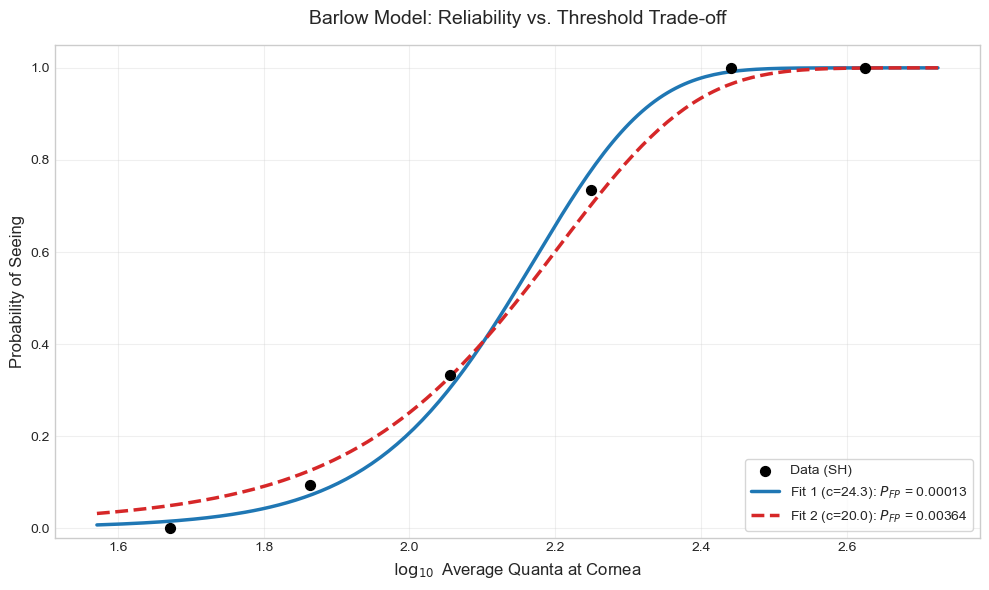

In [214]:
# Parameters for Case 1 (High Threshold / High Reliability)
eff1, x1, c1 = 0.09875, 10.0475, 24.2951
# Parameters for Case 2 (Lower Threshold / Lower Reliability)
eff2, x2, c2 = 0.068, 10.0475, 20.0


log_N_smooth = np.linspace(df_sh['quanta'].min() - 0.1, df_sh['quanta'].max() + 0.1, 200)
N_smooth_lin = 10**log_N_smooth

fit1 = barlow_model(N_smooth_lin, eff1, x1, c1)
fit2 = barlow_model(N_smooth_lin, eff2, x2, c2)

fp_rate1 = poisson.sf(round(c1) - 1, x1)
fp_rate2 = poisson.sf(round(c2) - 1, x2)


plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')


plt.scatter(df_sh['quanta'], df_sh['prob'], color='black', s=50, label='Data (SH)', zorder=5)

# Plot Case 1
plt.plot(log_N_smooth, fit1, color='tab:blue', lw=2.5, 
         label=f'Fit 1 (c={c1:.1f}): $P_{{FP}}$ = {fp_rate1:.5f}')

# Plot Case 2
plt.plot(log_N_smooth, fit2, color='tab:red', linestyle='--', lw=2.5, 
         label=f'Fit 2 (c={c2:.1f}): $P_{{FP}}$ = {fp_rate2:.5f}')


plt.title('Barlow Model: Reliability vs. Threshold Trade-off', fontsize=14, pad=15)
plt.xlabel(r'$\log_{10}$ Average Quanta at Cornea', fontsize=12)
plt.ylabel('Probability of Seeing', fontsize=12)
plt.ylim(-0.02, 1.05)
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(alpha=0.3)


print(f"--- Reliability Comparison ---")
print(f"Case 1 (c={c1:.1f}, x={x1:.1f}): FP Rate = {fp_rate1:.6f} ({fp_rate1*100:.4f}%)")
print(f"Case 2 (c={c2:.1f}, x={x2:.1f}): FP Rate = {fp_rate2:.6f} ({fp_rate2*100:.4f}%)")
print(f"The decrease in threshold multiplied the False Positive rate by a factor of ~{fp_rate2/fp_rate1:.1f}x.")

plt.tight_layout()
plt.show()

The $x$ value is imposed by nature and the external conditions of your lab, therefore what we can change is efficiency and threshold. Notice, however, that lowering the threshold comes at the cost of increasing our false positive rates. This makes perfect sense and explains discrepancies in classical experiments in visual perception.

## "Multiplication Noise in the Human Visual System at Threshold 3. The Role of Non-Poisson Quantum Fluctuations"

In this triad of articles Teich et. al described a model which takes into account another type of noise: multiplicative Poisson noise, which describes the noise that arises from neural pathways in addition to the additive poissonian noise described by Barlow. This part will not really focus on the details of the three articles, since the statistics is pretty deep. Here I will first describe the sub-section:

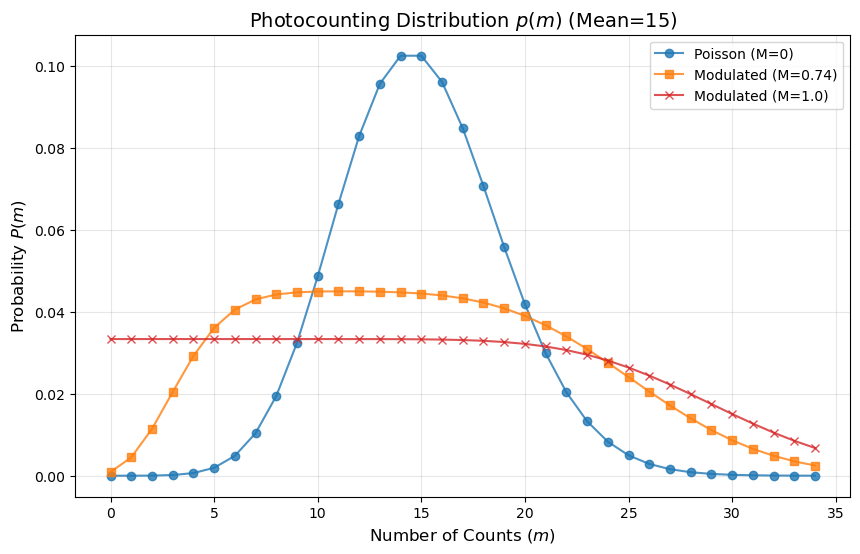

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

def barlow_modulated_pmf(m, m_mean, M):
    """
    Implements Eq. (2) from Teich et al. (1982):
    The photocounting distribution for triangularly modulated Poisson light.
    """
    if M <= 1e-5: # Case for M=0 (Standard Poisson)
        return poisson.pmf(m, m_mean)
    
    # Range of intensity fluctuations 
    mu_low = m_mean * (1 - M)
    mu_high = m_mean * (1 + M)
    
    # poisson.cdf(m, mu) is the sum from i=0 to m of exp(-mu)*mu^i / i!
    # The probability is the difference of CDFs scaled by 1/(2*M*mean)
    p_m = (poisson.cdf(m, mu_low) - poisson.cdf(m, mu_high)) / (2 * M * m_mean)
    return p_m

# Parameters
m_mean = 15
m_values = np.arange(0, 35)
modulation_depths = [0, 0.74, 1.0]
colors = ['tab:blue', 'tab:orange', 'tab:red']
markers = ['o', 's', 'x']

plt.figure(figsize=(10, 6))

for M, color, marker in zip(modulation_depths, colors, markers):
    probs = [barlow_modulated_pmf(m, m_mean, M) for m in m_values]
    label = f'Poisson (M=0)' if M == 0 else f'Modulated (M={M})'
    plt.plot(m_values, probs, marker=marker, color=color, label=label, alpha=0.8)

plt.title(f'Photocounting Distribution $p(m)$ (Mean={m_mean})', fontsize=14)
plt.xlabel('Number of Counts ($m$)', fontsize=12)
plt.ylabel('Probability $P(m)$', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

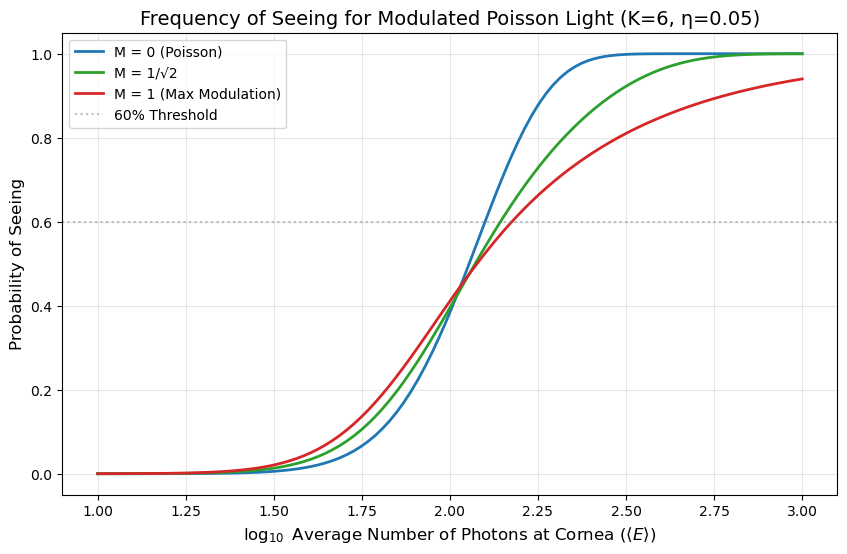

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

def teich_pmf(m, m_mean, M):
    """
    Photocounting distribution for triangularly modulated Poisson light.
    Eq (2) in Teich et al. (1982).
    """
    if M <= 1e-6:
        return poisson.pmf(m, m_mean)
    
    mu_low = m_mean * (1 - M)
    mu_high = m_mean * (1 + M)
    
    # The term in brackets is the difference of two Poisson CDFs
    return (poisson.cdf(m, mu_low) - poisson.cdf(m, mu_high)) / (2 * M * m_mean)

def p_see_modulated(N_avg, M, K, eta):
    """
    Frequency of seeing P_see = sum_{j=K}^{inf} p(j)
    """
    m_mean = eta * N_avg
    # For a high precision, we sum up to a point where prob is negligible
   
    j_values = np.arange(K, max(int(m_mean * 3), K + 50))
    probs = [teich_pmf(j, m_mean, M) for j in j_values]
    return np.sum(probs)

# Parameters
K = 6           # Standard threshold (Hecht et al.)
eta = 0.05      # Standard quantum efficiency (5%)
N_range = np.logspace(1, 3, 100) # Corneal quanta from 10 to 1000
M_values = [0, 1/np.sqrt(2), 1]
labels = ['M = 0 (Poisson)', 'M = 1/√2', 'M = 1 (Max Modulation)']
colors = ['tab:blue', 'tab:green', 'tab:red']

plt.figure(figsize=(10, 6))

for M, label, color in zip(M_values, labels, colors):
    p_detection = [p_see_modulated(N, M, K, eta) for N in N_range]
    plt.plot(np.log10(N_range), p_detection, label=label, color=color, lw=2)

plt.axhline(0.6, color='gray', linestyle=':', alpha=0.5, label='60% Threshold')
plt.title(f'Frequency of Seeing for Modulated Poisson Light (K={K}, η={eta})', fontsize=14)
plt.xlabel(r'$\log_{10}$ Average Number of Photons at Cornea ($\langle E \rangle$)', fontsize=12)
plt.ylabel('Probability of Seeing', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Note on S-shaped curves in Psychophysics:

<div class="alert alert-warning">
<b></b> This discussion is based on Chapter 4, <em>Psychometric Functions</em>, of the book <em>Psychophysics: A Practical Introduction</em>.
</div>

Inspired by the question: *Are all psychophysics processes described by Cumulative Poisson functions?*

Note that the cumulative Poisson distribution function is an S-shaped curve, which is quite common in psychophysics experiments. This, however, was a *coincidence*; psychophysics experiments lead to S-curve distributions, which are described by many different functions. We will first describe the **basics** of the underlying theory and proceed to list the functions (just like in Chapter 4). 

Psychometric functions are in general S-shaped and can be defined by four parameters, two of which will be most relevant now: $\alpha$ and $\beta$. The $\alpha$ parameter describes the position of the curve along the $x$-axis. This essentially gives us the **threshold** for our experiment, since it shows when the probability of seeing starts to increase given a stimulus. The $\beta$ parameter gives us the slope of our curve. It tells us how much the variations in the stimulus intensity really affect the probability of seeing. 

In typical psychophysics experiments, these two variables are the ones that need to be found after collecting the data. This is usually done with Maximum Likelihood algorithms.

<div class="alert alert-info">
<b>Coincidence:</b> the term coincidence is not the best. I mean it in the sense that they used this function, because of the light and not because they knew it was S-shaped like in other psycophysics experiments. However, the fact that the response to light in their experiments also presented itself as a S-shaped curve is probabily no coincidence. The way humans respond to stimulus is well described by these curves, therefore it makes sense that this was the case in Hechts experiments too. An interesting idea, may be to attempt to fit their data with different functions and attempt a reinterpretation. Notice that there is no right answer to deciding functions, they are chosen a priori, based on models we formulate. 
</div>

The code below shows how changing $\beta$ and $\alpha$ changes our curve. All of these graphs attempt to simulate an experiment that increses the intensity of a stimulus and the observer says that it has seen it or not, for example. This would be done many times and the proability would correspond to the frequency of times they say that they saw it. 



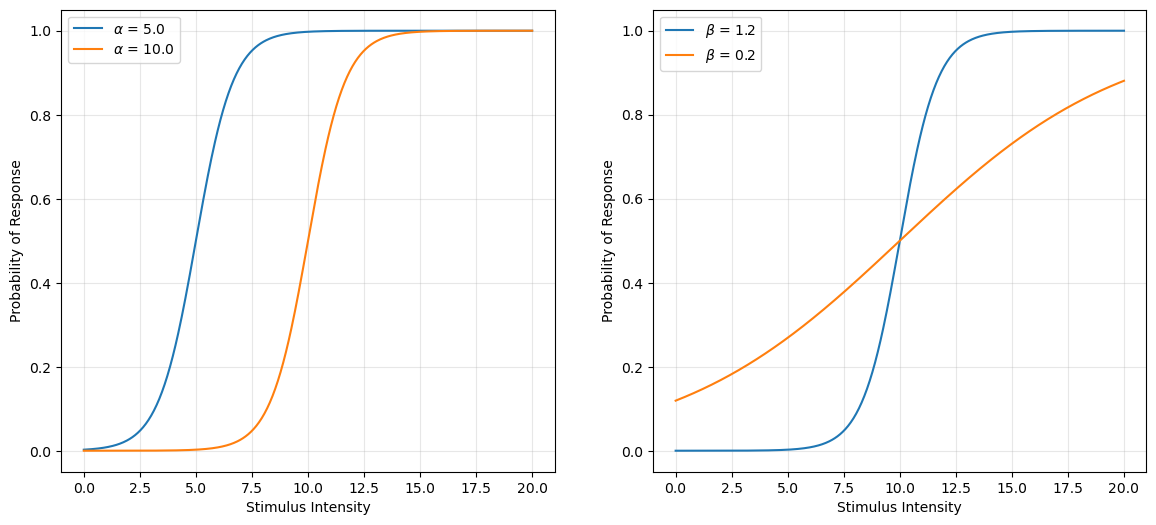

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) 
y_logi = psychometric(f_logistic(x_linear, alpha_lin, beta_lin), gamma, lambd)
x_linear = np.linspace(0, 20, 500)
alpha_lin = 5.0  # Threshold at 5
alpha_lin2 = 10.0

beta_lin = 1.2 # Slope
beta_lin2 = 0.2

gamma = 0.0      # Yes/No task (0% guess rate)
lambd = 0.0      # Perfect observer (0% lapse rate)

ax1.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin, beta_lin), gamma, lambd), label = f'$\\alpha$ = {alpha_lin}' )
ax1.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin2, beta_lin), gamma, lambd), label = f'$\\alpha$ = {alpha_lin2}' )

ax2.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin2, beta_lin), gamma, lambd), label = f'$\\beta$ = {beta_lin}' )
ax2.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin2, beta_lin2), gamma, lambd), label = f'$\\beta$ = {beta_lin2}' )


for i in (ax1,ax2):
    i.set_xlabel('Stimulus Intensity')
    i.set_ylabel('Probability of Response')
    
    i.legend()
    i.grid(alpha=0.3)
    
plt.show()



In order to determine the Psychometric Function (PF) fully, we also need to understand $\gamma$ and $\lambda$. While $\alpha$ and $\beta$ determine properties of the underlying sensory mechanism (sensitivity of vision), $\gamma$ and $\lambda$ describe the experiment and its subject. These parameters correspond to the guessing rate and the lapse rate, respectively.

* Guessing rate ($\gamma$): If an observer were to guess, what is the probability of getting it right? In yes/no experiments (like Hecht's), we can say that this parameter is zero because you either saw it or not. However, in M-alternative forced-choice (M-AFC) experiments, this rate can be given by $1/m$ (where $m$ is the number of response choices in the experiment , notice that M and m may be different).

* Lapse rate ($\lambda$): If you were to blink when the light was supposed to hit your eyes but respond anyway, you might get it wrong even though the stimulus level is high. So, this parameter attempts to encapsulate the attentiveness of the observer. 

Both of these parameters are typically determined a priori to the fitting of our function, since they relate to the experiment itself and not to the sensory mechanism. 

---
*Just a comment: I believe these definitions are quite dependent on the interpretation we give our data and the kind of experiment we will be performing. Currently, I will not dive deeper into this (because of a lack of knowledge), but Chapter 4 discusses this point when talking about High Threshold Theory and Signal Detection Theory (theories to determine when a sensory stimulus was actually perceived).*

---
So, how do these parameters turn up in these functions?

The PF relates performance on a psychophysical task to some characteristic of the stimulus. The performance on the task as a function of the stimulus can be written as $\psi(x; \alpha, \beta, \gamma, \lambda)$. What we are really interested in, however, is the underlying sensory mechanism and its sensitivity to a given stimulus. This will be described by the function $F(x; \alpha, \beta)$. So, in experiments, what we truly measure is $\psi(x)$, even though we really want $F(x)$. In order to relate $\psi(x)$ and $F(x)$, we will have to use some HTT, which will give us an explicit relation. This, however, is not the only way to relate them (once again, I will not go further because of a lack of knowledge on this topic, but during the group reunions, we will talk about this more). 

The relation comes from a tree of possible responses which lead to either correct (saying you saw the stimulus when it was present, or saying you didn't see it when there was none) or incorrect (saying you saw the stimulus when there was none, or didn't see it when it was present) responses. These responses have to do with $\gamma$ (guessing) and $\lambda$ (probability of an incorrect response independent of the stimulus). The expression is:

$$
\psi(x;\alpha, \beta, \gamma, \lambda) = \gamma + (1 - \gamma - \lambda)F(x;\alpha,\beta)
$$

The book presents a derivation that comes from the tree presented below. This, however, uses $\lambda^*$, which gives it a different interpretation, although it may be more "correct." Here, $\lambda^*$ refers to the probability with which the observer responds independently of the value of $x$ (not necessarily incorrectly). I didn't really understand the relation between $\lambda^*$ and $\lambda$, so I will not dive deeper here in this notebook, but we can discuss it.


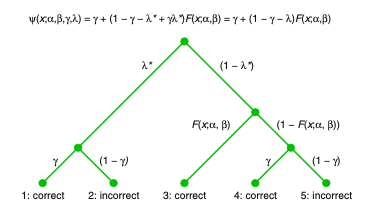

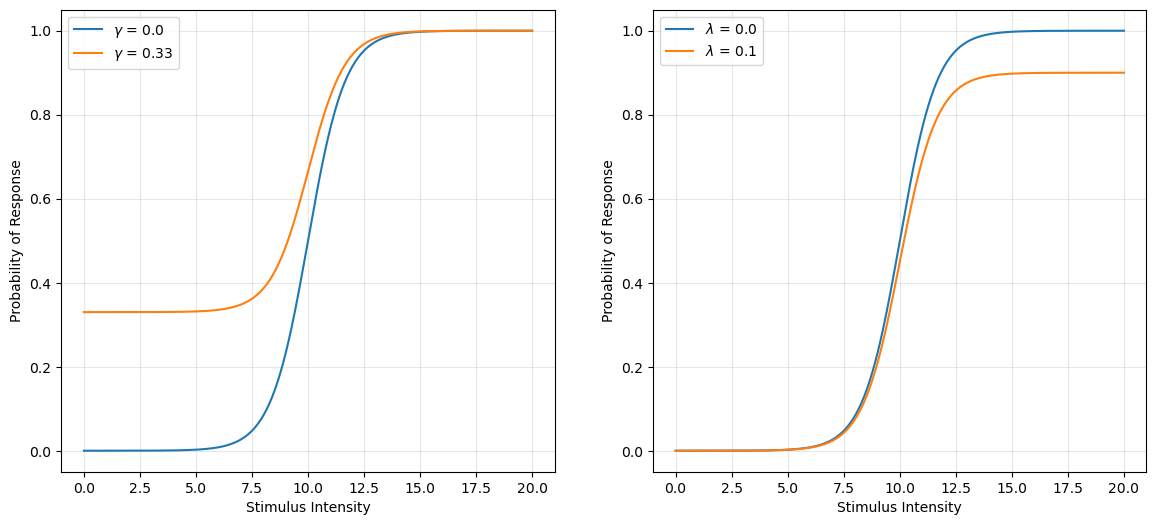

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) 
y_logi = psychometric(f_logistic(x_linear, alpha_lin, beta_lin), gamma, lambd)
x_linear = np.linspace(0, 20, 500)
alpha_lin = 10.0  # Threshold at 5

beta_lin = 1.2 # Slope

gamma = 0.0  # Yes/No task (0% guess rate)
gamma1 = 0.33 # 3AFC
lambd = 0.0   # Perfect observer (0% lapse rate)
lambd1 = 0.1

ax1.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin, beta_lin), gamma, lambd), label = f'$\\gamma$ = {gamma}' )
ax1.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin, beta_lin), gamma1, lambd), label = f'$\\gamma$ = {gamma1}' )

ax2.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin2, beta_lin), gamma, lambd), label = f'$\\lambda$ = {lambd}' )
ax2.plot(x_linear,psychometric(f_logistic(x_linear, alpha_lin2, beta_lin), gamma, lambd1), label = f'$\\lambda$ = {lambd1}' )


for i in (ax1,ax2):
    i.set_xlabel('Stimulus Intensity')
    i.set_ylabel('Probability of Response')
    
    i.legend()
    i.grid(alpha=0.3)
    
plt.show()


### gamma: apesar de nao estar percebendo o estimulo, ela da um chute e tem probabilidade 1/3 de acertar, logo esse seria um minimo de prob de acerto
# lambda: como essa pessoa é desatenta, apesar do estimulo alto ela erra, colocando um limite superior na probabilidade de resposta

Functions:

* **Weibull**: 
$$F(x; \alpha, \beta) = 1 - \exp\left(-\left(\frac{x}{\alpha}\right)^\beta\right)$$

* **Cumulative Normal**: 
$$F(x; \alpha, \beta) = \frac{1}{\beta \sqrt{2\pi}} \int_{-\infty}^{x} \exp\left(-\frac{(t-\alpha)^2}{2\beta^2}\right) dt$$

* **Cumulative Poisson**: 
$$F(x; k) = \sum_{j=k}^{\infty} \frac{x^j e^{-x}}{j!}$$

* **Logistic**: 
$$F(x; \alpha, \beta) = \frac{1}{1 + \exp(-\beta(x - \alpha))}$$

* **Gumbel (Log-Weibull)**: 
$$F(x; \alpha, \beta) = 1 - \exp(-10^{\beta(x - \alpha)})$$

* **Quick**: 
$$F(x; \alpha, \beta) = 1 - 2^{-\left(\frac{x}{\alpha}\right)^\beta}$$

* **Log-Quick**: 
$$F(x; \alpha, \beta) = 1 - 2^{-10^{\beta(x - \alpha)}}$$

* **Hyperbolic Secant**: 
$$F(x; \alpha, \beta) = \frac{2}{\pi} \arctan\left(\exp\left(\frac{\pi}{2} \beta (x - \alpha)\right)\right)$$

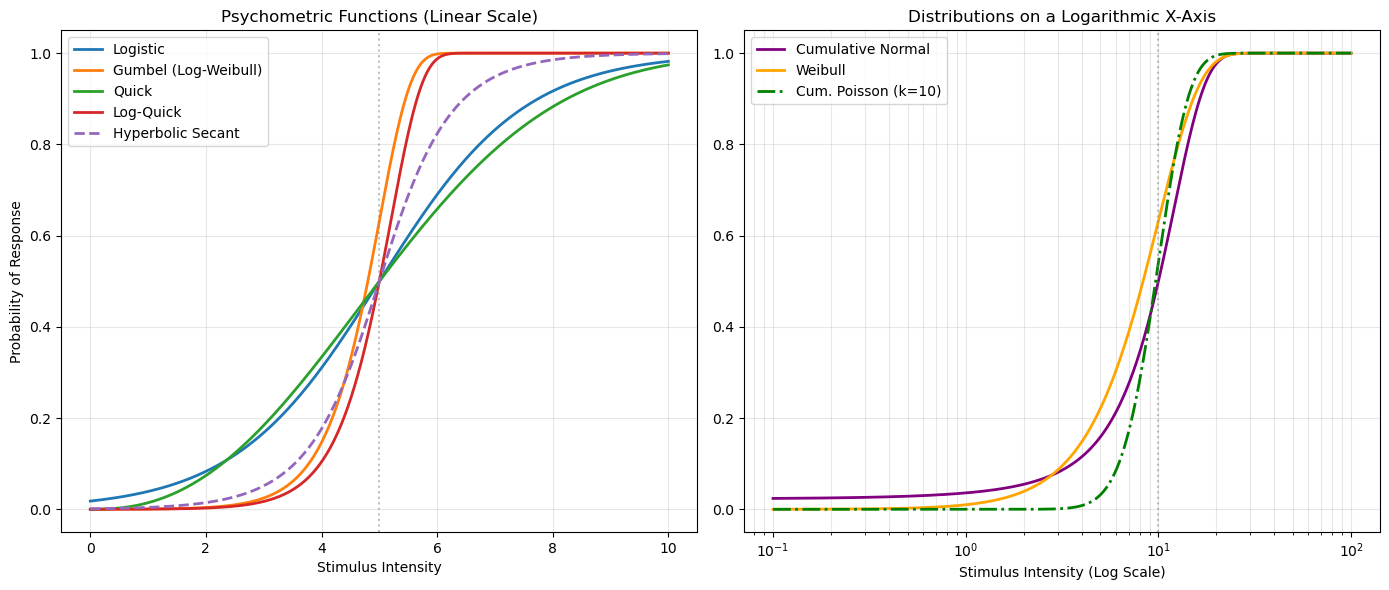

In [10]:
# ==========================================
# 1. Define the Underlying Sigmoid Functions
# ==========================================

def f_logistic(x, alpha, beta):
    return 1 / (1 + np.exp(-beta * (x - alpha)))

def f_gumbel(x, alpha, beta):
    # Often used as the Log-Weibull in psychophysics
    return 1 - np.exp(-10**(beta * (x - alpha)))

def f_quick(x, alpha, beta):
    # Defined for x > 0
    x_safe = np.maximum(x, 1e-10)
    return 1 - 2**(-(x_safe / alpha)**beta)

def f_log_quick(x, alpha, beta):
    return 1 - 2**(-10**(beta * (x - alpha)))

def f_hyp_secant(x, alpha, beta):
    return (2 / np.pi) * np.arctan(np.exp((np.pi / 2) * beta * (x - alpha)))

def f_weibull(x, alpha, beta):
    x_safe = np.maximum(x, 1e-10)
    return 1 - np.exp(-(x_safe / alpha)**beta)

def f_cum_normal(x, alpha, beta):
    # alpha = mean, beta = standard deviation (inverse of slope)
    return norm.cdf(x, loc=alpha, scale=beta)

def f_cum_poisson(x, k):
    # Probability of getting k or more events given mean x
    # This is equivalent to 1 - CDF(k-1)
    return poisson.sf(k - 1, x)

# ==========================================
# 2. The 4-Parameter Psychometric Wrapper
# ==========================================

def psychometric(F_val, gamma, lambd):
    """ Scales the underlying sigmoid F_val using guess (gamma) and lapse (lambd) """
    return gamma + (1 - gamma - lambd) * F_val

# ==========================================
# 3. Setup and Plot 1: The New Functions
# ==========================================

x_linear = np.linspace(0, 10, 500)
alpha_lin = 5.0  # Threshold at 5
beta_lin = 0.8   # Slope
gamma = 0.0      # Yes/No task (0% guess rate)
lambd = 0.0      # Perfect observer (0% lapse rate)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Calculate Plot 1 curves
y_logi = psychometric(f_logistic(x_linear, alpha_lin, beta_lin), gamma, lambd)
y_gumb = psychometric(f_gumbel(x_linear, alpha_lin, beta_lin), gamma, lambd)
y_quic = psychometric(f_quick(x_linear, alpha_lin, beta_lin*3), gamma, lambd) # Adjusted slope for visual comparison
y_logq = psychometric(f_log_quick(x_linear, alpha_lin, beta_lin), gamma, lambd)
y_hyps = psychometric(f_hyp_secant(x_linear, alpha_lin, beta_lin), gamma, lambd)

ax1.plot(x_linear, y_logi, label='Logistic', lw=2)
ax1.plot(x_linear, y_gumb, label='Gumbel (Log-Weibull)', lw=2)
ax1.plot(x_linear, y_quic, label='Quick', lw=2)
ax1.plot(x_linear, y_logq, label='Log-Quick', lw=2)
ax1.plot(x_linear, y_hyps, label='Hyperbolic Secant', lw=2, linestyle='--')

ax1.set_title('Psychometric Functions (Linear Scale)')
ax1.set_xlabel('Stimulus Intensity')
ax1.set_ylabel('Probability of Response')
ax1.axvline(alpha_lin, color='gray', linestyle=':', alpha=0.5)
ax1.legend()
ax1.grid(alpha=0.3)

# ==========================================
# 4. Setup and Plot 2: Log Scale Comparison
# ==========================================

x_log = np.logspace(-1, 2, 500) # Values from 0.1 to 100
alpha_log = 10.0 # Threshold at 10

# Calculate Plot 2 curves
# For normal, beta is standard deviation. For Weibull, beta is shape.
y_norm = psychometric(f_cum_normal(x_log, alpha_log, 5.0), gamma, lambd)
y_weib = psychometric(f_weibull(x_log, alpha_log, 2.0), gamma, lambd)

# For Poisson, alpha_log acts as the mean photon count. We want the threshold (k)
# to be around 10 so it crosses 0.5 near our other functions.
k_threshold = 10 
y_pois = psychometric(f_cum_poisson(x_log, k_threshold), gamma, lambd)

ax2.plot(x_log, y_norm, label='Cumulative Normal', color='purple', lw=2)
ax2.plot(x_log, y_weib, label='Weibull', color='orange', lw=2)
ax2.plot(x_log, y_pois, label=f'Cum. Poisson (k={k_threshold})', color='green', lw=2, linestyle='-.')

ax2.set_title('Distributions on a Logarithmic X-Axis')
ax2.set_xlabel('Stimulus Intensity (Log Scale)')
ax2.set_xscale('log') # This is the magic line!
ax2.axvline(alpha_log, color='gray', linestyle=':', alpha=0.5)
ax2.legend()
ax2.grid(alpha=0.3, which='both') # Show minor grid lines for log scale

plt.tight_layout()
plt.show()

### this code was generated by gemini

In [41]:
df_sh

,quanta,prob
0,1.671173,0.000
1,1.863917,0.094
2,2.056142,0.333
3,2.248954,0.735
4,2.441066,1.000
5,2.625004,1.000


--- SciPy Gumbel Fit Results ---
Log Threshold (alpha_log): 2.2023
Linear Threshold (10^alpha): 159.3310
Slope (beta): 2.8700



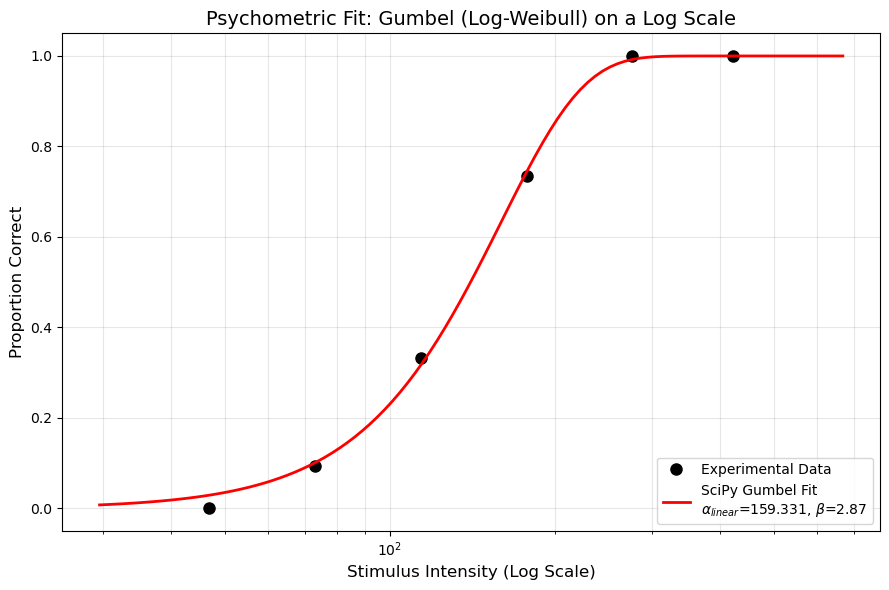

In [47]:
from scipy.optimize import curve_fit

stimuli_log = np.asarray(df_sh['quanta'])
stimuli_linear = 10**stimuli_log
probabilities = np.asarray(df_sh['prob'])


# ==========================================
# 2. The SciPy Method
# ==========================================
def fit_gumbel(x_log, alpha_log, beta):
    gamma = 0.  # Fixed guess rate for 2AFC
    lambd = 0. # Fixed lapse rate
    
    # Gumbel core function
    F = 1 - np.exp(-10**(beta * (x_log - alpha_log)))
    
    # Scale with gamma and lambda
    return gamma + (1 - gamma - lambd) * F

# Initial guesses: Start alpha near the median of our log data
initial_guesses = [np.median(stimuli_log), 2.0] 

# Run the optimization on the LOG data
popt, pcov = curve_fit(fit_gumbel, stimuli_log, probabilities, p0=initial_guesses)
best_alpha_log, best_beta = popt

print("--- SciPy Gumbel Fit Results ---")
print(f"Log Threshold (alpha_log): {best_alpha_log:.4f}")
print(f"Linear Threshold (10^alpha): {10**best_alpha_log:.4f}") # Convert back to physical units
print(f"Slope (beta): {best_beta:.4f}\n")



x_smooth_log = np.linspace(stimuli_log.min() - 0.2, stimuli_log.max() + 0.2, 100)
y_fit = fit_gumbel(x_smooth_log, best_alpha_log, best_beta)

# Convert the smooth log x-values BACK to linear space for plotting
# This allows Matplotlib to display the actual physical units on the axis
x_smooth_linear = 10**x_smooth_log

plt.figure(figsize=(9, 6))

# Plot the raw experimental data
plt.plot(stimuli_linear, probabilities, 'ko', label='Experimental Data', markersize=8)

# Plot the smooth SciPy fit
plt.plot(x_smooth_linear, y_fit, 'r-', 
         label=f'SciPy Gumbel Fit\n$\\alpha_{{linear}}$={10**best_alpha_log:.3f}, $\\beta$={best_beta:.2f}', lw=2)


plt.xscale('log') 

plt.title('Psychometric Fit: Gumbel (Log-Weibull) on a Log Scale', fontsize=14)
plt.xlabel('Stimulus Intensity (Log Scale)', fontsize=12)
plt.ylabel('Proportion Correct', fontsize=12)
plt.legend(loc='lower right')

# Use 'both' to show minor gridlines, which really helps visualize log scales
plt.grid(alpha=0.3, which='both') 
plt.tight_layout()
plt.show()

### Biophysics Ex. 5:
After this long digression lets come back to the books exercises. 

In [66]:
df_cmean = (dfm_sh+dfm_ss+df_mhp)/3

In [67]:
df_mean

,quanta,prob
0,1.537399,0.020000
1,1.731723,0.054833
2,1.925828,0.252167
3,2.121505,0.639167
4,2.318237,0.935833
5,2.512840,1.000000


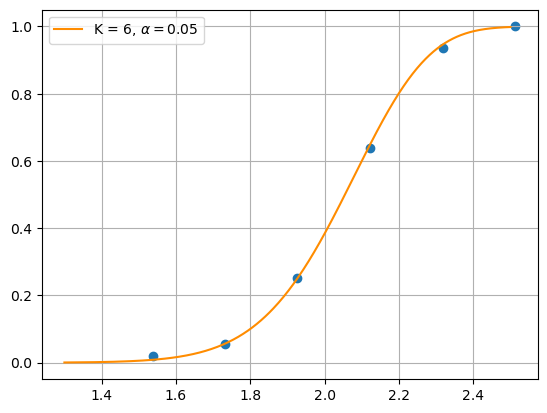

In [73]:

fit_ss = [prob_see_scipy(0.05, j, 6) for j in quantass]

plt.scatter(df_mean['quanta'], df_mean['prob'])
fit_mean = [prob_see_scipy(0.05, j, 6) for j in quantass]
plt.plot(np.log10(quantass), fit_ss, label = r'K = 6, $\alpha = 0.05$', c = 'darkorange')


plt.grid()
plt.legend()
plt.show()

The book says that by taking the averages of all the data would lead to wrong results, especially because of the $\alpha$ parameter, which is different for each observer. This, however, was not the case. I still found a result that matched the expected amount of photons (between 5 and 7). 

## Ex. 8:


Once we have measured rod cells individually using suction-electrode techniques we can observe the current that passes through the cell once we have flashed light on to it. This method permits us to investigate wheter or not these cells respond to single photon stimuli. Now we will attempt to model the rod cells current and it's response to light. 

The noise is inherent to this kind of phenomena, we can model it as gaussian with variance $\sigma_0^2$. Therefore the current $i$ is taken from the following distribution, given that no photons were identified:

$$
P(i|n=0) = \frac{1}{\sqrt{2 \pi \sigma_0^2}}exp[-\frac{i^2}{2\sigma_0^2}]
$$

Once we consider that one photon has arrived we will need to take in consideration the noise that is inheritent of this measurement also, Gaussian with variance $\sigma_1^2$. Also the arrivale leads to a mean current $<i> = i_1$. Since the arrivals are independent:

$$
P(i|n=1) = \frac{1}{2 \pi (\sigma_0^2 + \sigma_1^2)}exp[-\frac{(i - i_1)^2 }{\sqrt{2(\sigma_0^2+ \sigma_1^2)}}]
$$

This can be generalized to n photons:

$$
P(i|n) = \frac{1}{2 \pi (\sigma_0^2 + n\sigma_1^2)}exp[-\frac{(i - ni_1)^2 }{\sqrt{2(\sigma_0^2+ n\sigma_1^2)}}]
$$

This is because of the independence of the random variables (background noise $\cal{N(0, \sigma_0^2)}$ and fluctuation response to the photon arrival $\cal{N(i_1, \sigma_1^2}$). We know the expectation and variance of the R.V individually and using the properties:



$$
E[X + Y] = E[X] + E[Y]  \\ \text{   this is a property of the expectation function}
$$


$$
E[XY] = E[X] E[Y] \\ \text{   this is a true only for independent variables and is easily shown using integrals}
$$


$$
Var[X + Y] = Var[X] + Var[Y]  \\ \text{   this is true for independent variables and is shown using the definition of variance in terms of expectation}
$$


We can get the probability distribution of the current only(knowing that the intervals are given by poisson distributions, since photon arrival is a poisson process):

$$
P(i) = \sum_j = P(i|j)P(j) \\
     = \sum_jP(i|j) e^{-m}\frac{m^j}{j!}
$$

Where m is the mean photon arrival of the poisson distribution 

Now let's first plot this function and than attempt to simulate it.

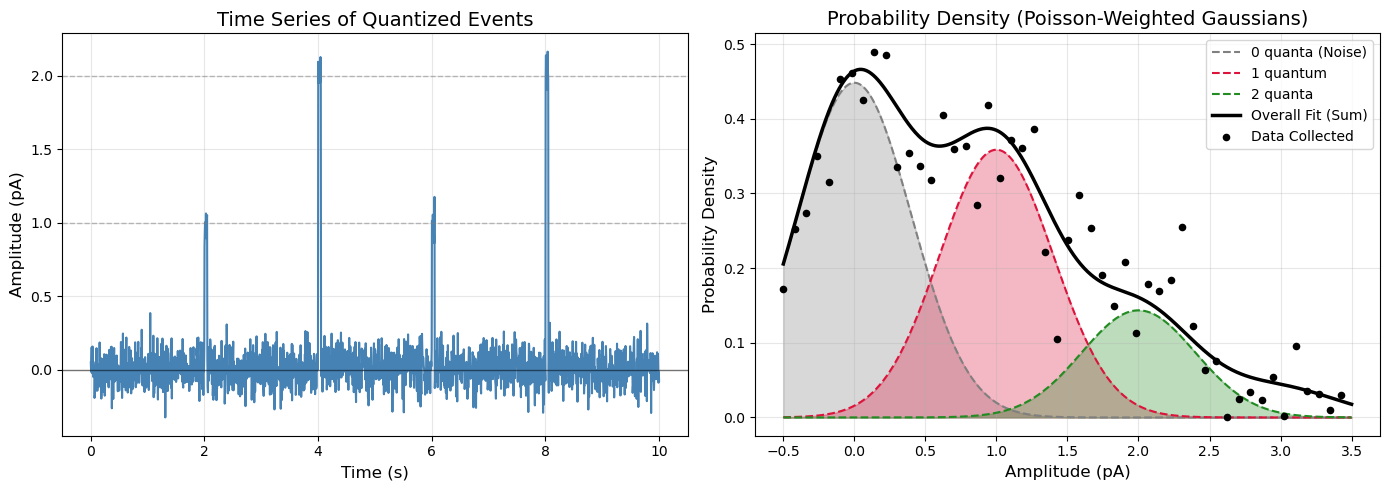

In [12]:
# ==========================================
# 1. Generate the Time Series Data
# ==========================================
np.random.seed(42) # For reproducible random noise
n_points = 2000
time = np.linspace(0, 10, n_points)

# Base thermal noise (0 pA mean, 0.1 pA std)
signal = np.random.normal(loc=0.0, scale=0.1, size=n_points)

# Add specific events (simulating, for example, 50ms channel openings)
pulse_width = 10 

# Two events of 1 pA
signal[400:400+pulse_width] += 1.0
signal[1200:1200+pulse_width] += 1.0

# Two events of 2 pA
signal[800:800+pulse_width] += 2.0
signal[1600:1600+pulse_width] += 2.0

# ==========================================
# 2. Generate the Probability Density Data
# ==========================================
# Define the physical parameters
A = 1.0       # Amplitude per quantum (1 pA)
sigma = 0.4   # Gaussian noise standard deviation (0.1 pA)
lam = 0.8     # Poisson mean (average quanta per measurement window)

x_amp = np.linspace(-0.5, 3.5, 500)
total_fit = np.zeros_like(x_amp)
individual_gaussians = []

# Calculate the Poisson-weighted Gaussians (for n = 0, 1, 2, 3 quanta)
for n in range(4):
    # Poisson weight (Probability of getting exactly n quanta)
    weight = poisson.pmf(n, lam)
    
    # Gaussian distribution for this specific quantum level
    gaussian = norm.pdf(x_amp, loc=n*A, scale=sigma)
    
    # The weighted component
    component = weight * gaussian
    individual_gaussians.append(component)
    
    # Add to the total envelope
    total_fit += component

# Simulate "Collected Data" points by adding a little noise to the total fit
# (Scaling it so it looks like a histogram scatter plot)
data_x = x_amp[::10] # take every 10th point
data_y = total_fit[::10] + np.random.normal(0, 0.05, size=len(data_x))
data_y = np.clip(data_y, 0, None) # Probabilities can't be negative

# ==========================================
# 3. Plotting
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Time Series ---
ax1.plot(time, signal, color='steelblue', lw=1.5)
ax1.set_title('Time Series of Quantized Events', fontsize=14)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude (pA)', fontsize=12)
ax1.axhline(0, color='black', lw=1, alpha=0.5)
ax1.axhline(1, color='gray', linestyle='--', lw=1, alpha=0.5)
ax1.axhline(2, color='gray', linestyle='--', lw=1, alpha=0.5)
ax1.grid(alpha=0.3)

# --- Plot 2: Probability Density ---
# 1. Plot individual Gaussians
colors = ['gray', 'crimson', 'forestgreen', 'purple']
labels = ['0 quanta (Noise)', '1 quantum', '2 quanta', '3 quanta']

for n in range(3): # Only plotting up to 2pA to match your prompt
    ax2.fill_between(x_amp, individual_gaussians[n], alpha=0.3, color=colors[n])
    ax2.plot(x_amp, individual_gaussians[n], color=colors[n], linestyle='--', label=labels[n])

# 2. Plot the Total Fit (Envelope)
ax2.plot(x_amp, total_fit, color='black', lw=2.5, label='Overall Fit (Sum)')

# 3. Plot the "Collected Data"
ax2.scatter(data_x, data_y, color='black', s=20, zorder=5, label='Data Collected')

ax2.set_title('Probability Density (Poisson-Weighted Gaussians)', fontsize=14)
ax2.set_xlabel('Amplitude (pA)', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
from math import factorial
def current_pd(i, m = 1, sigma_0 = 0.1, sigma_1 = 0.2,i_1 = 1):
    soma = 0
    for j in range(0, 500):
        soma += ( (m**j / factorial(j)) * np.exp(-m) ) * \
        ( np.exp( -((i - j*i_1)**2) / (2*(sigma_0**2 + j*sigma_1**2)) ) ) / \
        np.sqrt( 2*np.pi*(sigma_0**2 + j*sigma_1**2) )
    return soma

In [9]:
curr = np.linspace(-1., 4., 300)
pontos = [current_pd(i) for i in curr]

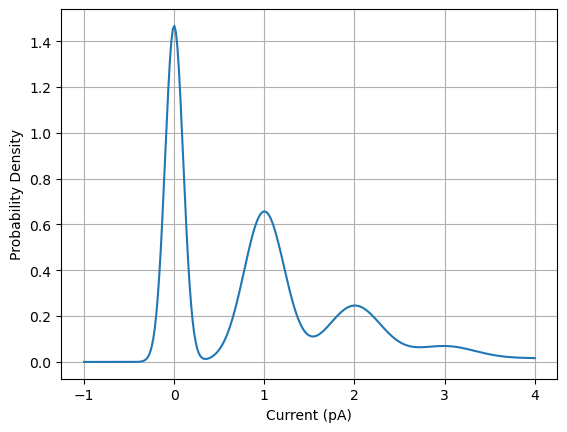

In [10]:
plt.plot(curr, pontos)
plt.xlabel('Current (pA)')
plt.ylabel('Probability Density')

plt.grid()
plt.show()


This the probability density which describes the **peak currents** (this is forced by the way we modelled the problem). What we are saying, since our assumption that these were measurements of photon detection, is that we are highly likely to measure 0 pA, then 1 pA, then 2 pA, then the rest is negligeble. Esssentially what we measured the most is the current at 0pA, which happens when 0 photons are absorved.


This is a strong indicator that our eyes can respond to quantized light, since the response to 0pA, 1pA, 2pA is distinct. Which means that by looking at the currents we can determine the amount of photons. 


Notice this is a sum of Gaussian distributions whose wheights are determined by Poisson probabilty of absorving a photon. 

Will our simulation of these processes also match our theory?

In [20]:
# parameters:

i1 = 1.0 # mean current for 1 photon
sigma0 = 0.1 # variance of noise 
sigma1 = 0.2 # variance of photon detection
m = 1.0 # average photon absorption 



In [25]:
def sim(N_samples, i1 = 1., sigma0 = 0.1, sigma1 = 0.2, m = 1):
    number_photons = np.random.poisson(m, N_samples)


    mean = i1 * number_photons

    std_dev = np.sqrt(sigma0**2 + (sigma1**2)*number_photons)

    currents_sim = np.random.normal(loc=mean, scale=std_dev)
    return currents_sim

sim1 = sim(350)

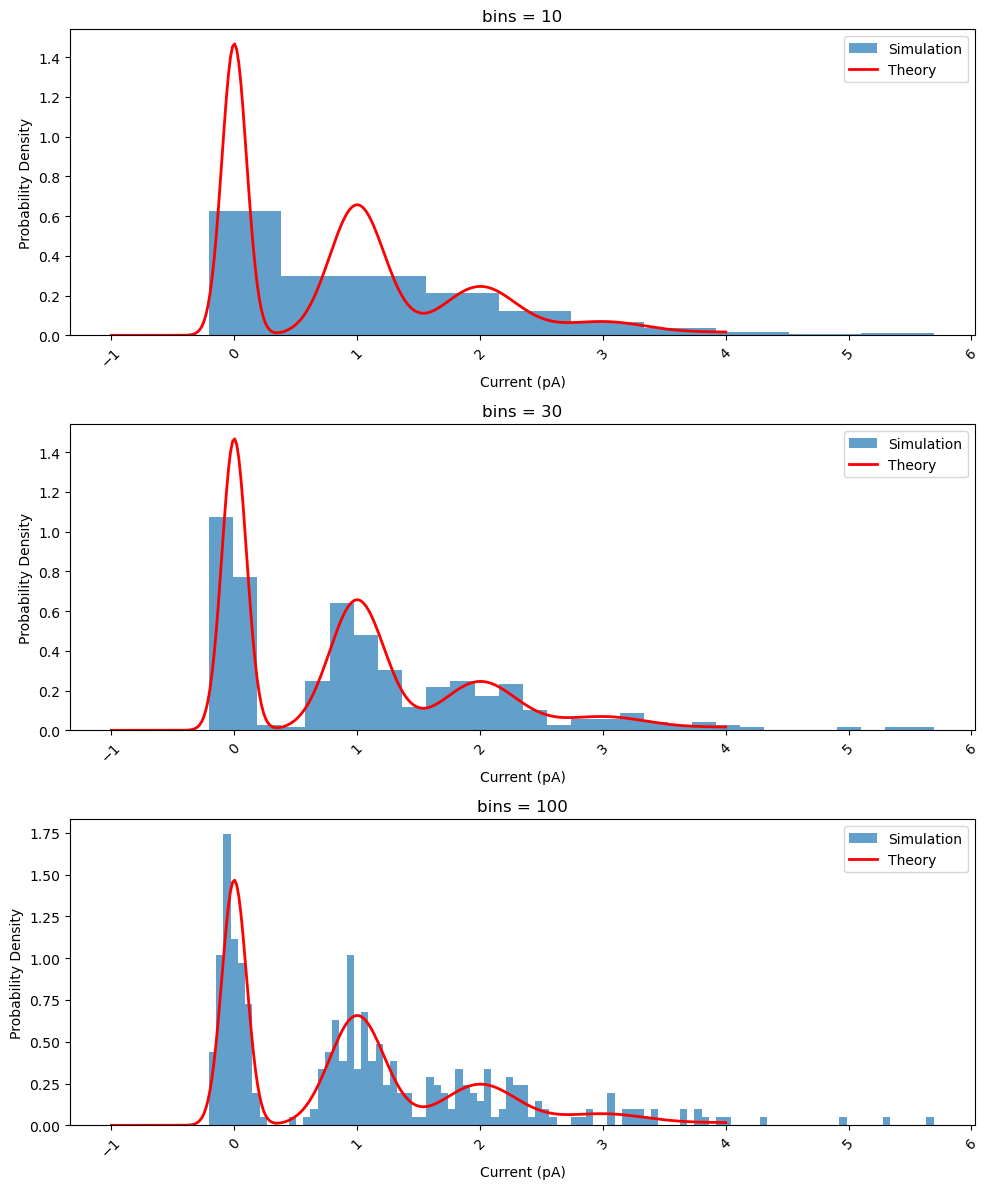

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(10,12 ))


axes = [ax1, ax2, ax3]
bins_list = [10,30,100] # number of bins
titles = ["bins = 10", "bins = 30", "bins = 100"] 
ticks = [-1., -0.5, 0., 0.5, 1., 2., 3., 4., 5.]


for ax, binss, title in zip(axes, bins_list, titles):
    
    # Plot the histogram (added alpha to make it slightly transparent)
    ax.hist(sim1, bins=binss, density=True, alpha=0.7, label='Simulation')
    
    # Plot the theoretical curve
    ax.plot(curr, pontos, 'r-', linewidth=2, label='Theory')
    
    
    ax.set_title(title)
    #ax.set_xticks(ticks)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('Current (pA)')
    ax.set_ylabel('Probability Density')
    ax.legend()


fig.tight_layout()
plt.show()

As it is pointed out in the book the more bins, more structure is revealed. However we have noisier results, notice the appearence of more points which are bigger then 4. I however do not see any trade-of, few bins leads to terrible visualizations. 

Now let's increase the number of samples

In [27]:
sim1 = sim(350)
sim2 = sim(1000)
sim3 = sim(100000)

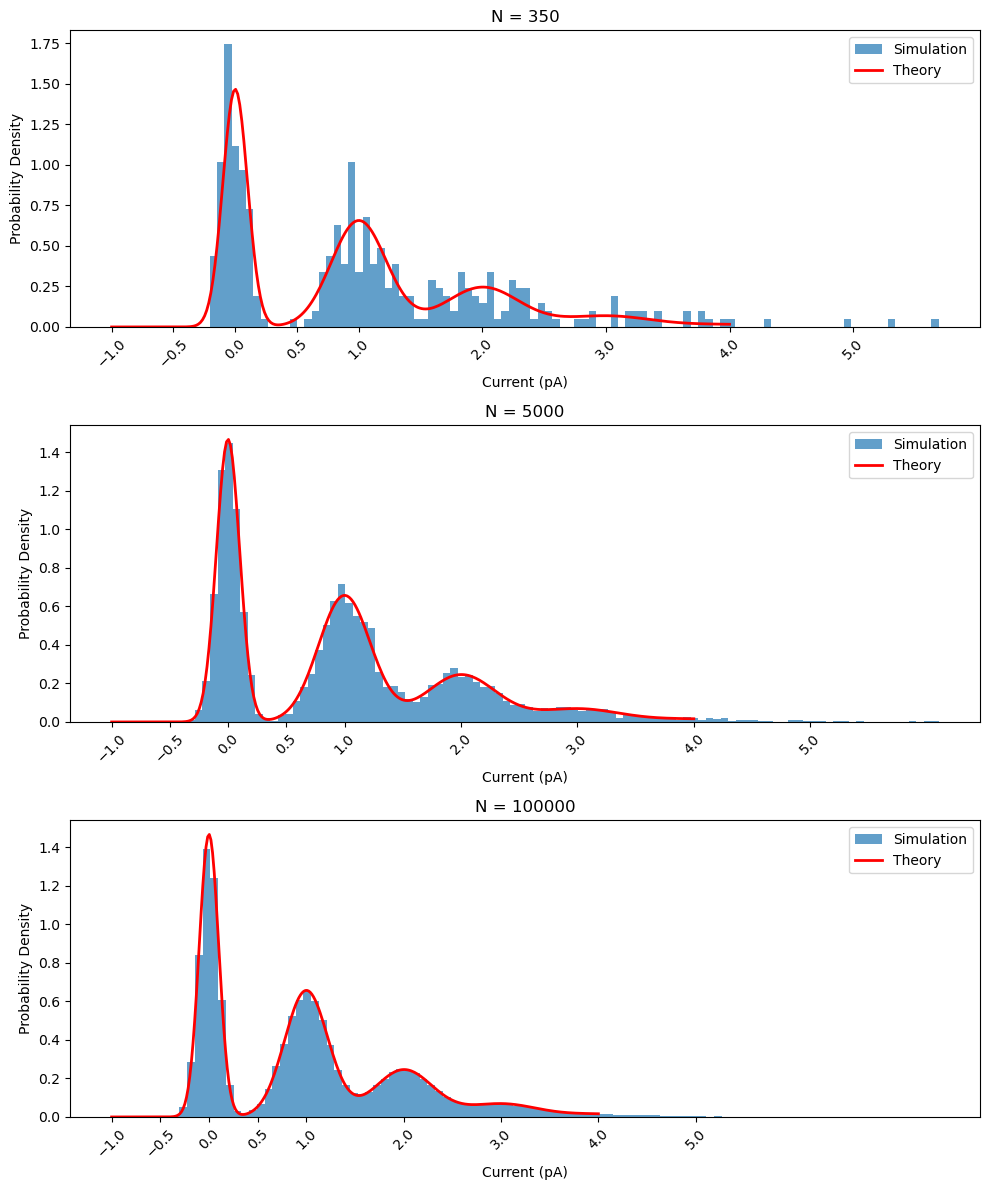

In [32]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(10,12 ))

axes = [ax1, ax2, ax3]
simulations = [sim1,sim2,sim3]
N = [350,1000,10000] # number of samples
titles = ["N = 350", "N = 5000", "N = 100000"]
ticks = [-1., -0.5, 0., 0.5, 1., 2., 3., 4., 5.]


for ax, s, title in zip(axes, simulations, titles):
    
    # Plot the histogram (added alpha to make it slightly transparent)
    ax.hist(s, bins=100, density=True, alpha=0.7, label='Simulation')
    
    # Plot the theoretical curve
    ax.plot(curr, pontos, 'r-', linewidth=2, label='Theory')
    
    ax.set_xlabel('Current (pA)')
    ax.set_ylabel('Probability Density')
    ax.set_title(title)
    ax.set_xticks(ticks)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('Current (pA)')
    ax.set_ylabel('Probability Density')
    ax.legend()


fig.tight_layout()
plt.show()

Notice that 350 samples is a very small amount of samples. It is still quite far from the real distribution. It does not really grasp the 3 peaks we would like to see. Also notice how the number of samples decreases the noise. Of course I have decided for a large number of bins, but still we can clearly see the difference for the least and the most amount of samples.



### Disclaimer: AI use

I first wrote the python functions and then asked Gemini to improve upon it, unless clearly stated. No substantial difference was provided, only improvements on iterations leading to less complexity - time consumed - or use of better libraries. Also used it to correct grammar.
